# <font color='#3d59c6'> MD004 SESIÓN Tratamiento de Datos </font>

**DATA**: En este ejemplo utilizaremos el dataset: **20220216_TratamientoDatos_SerieTitanic.csv**

- Transatlántico británico que naufragó en aguas del océano Atlántico la noche del 14 al 15 de abril de 1912
- Murieron 1496 personas de 2208
- En él viajaban algunas de las personas más ricas del mundo, pero también cientos de inmigrantes irlandesa, británicos y escandinavos
- Solo tenía **botes salvavidas para 1178 personas**
- Casi 900 personas que formaban parte de la tripulación del Titanic

- Pasajeros

 -  Las cenizas de los restos mortales cremados de los supervivientes Joseph Boxhall (1884-1967) -no está inluido en el dataset al ser tripulación-, **Frank Goldsmith (1902-1982)**, y **Ruth Elizabeth Becker (1899-1990)** fueron derramadas en la posición oceánica donde el Titanic había desaparecido décadas atrás.
 - La superviviente anglo-argentina **Violet Jessop (1887-1971)**, destacó por haber sobrevivido a los desastres marinos de los tres buques de la clase Olympic. Se encontraba a bordo cuando;
   - En 1911, el Olympic colisionó lateralmente contra el buque de guerra HMS Hawke.
   - Naufragó el Titanic.
   - En 1916, el tercer barco del trío, el Britannic, se fue al fondo marino en aguas griegas a consecuencia aparente del choque contra una mina submarina.
 - Al superviviente japonés **Masabumi Hosono (1870-1939)** se le reprochó en su país su salvación por avergonzar a su nación ante la mirada de Occidente, llegando incluso a perder su empleo en el gobierno


![image.png](attachment:image.png)

**OBJETIVO:** Observar nuestros datos para detectar todo aquello que nos pueda suponer un stopper puntual en el desarrollo de nuestro trabajo <font color='#C90076'> **(generación de modelos predictivos, migración de data...)** </font>: valores NAs, outliers,... y decidir que hacemos ante estos casos o para detectar la creación de alguna variable nueva a partir de nuestros datos.

**PASOS:**

0. Extracción de información a través del summary
1. Creación NEW VARIABLE
2. Transformación tipo DATOS
3. Filtrado OUTLIERS
4. Datos FALTANTES
5. Normalización
6. Estandarización
7. Discretización / Agrupación

## <font color='#3d59c6'>  CARGA DE PACKAGES </font>

El primer paso es preparar el entorno y cargar el conjunto de datos

In [ ]:
install.packages('vegan')
install.packages('gridExtra')
install.packages('caret')

Installing package into ‘/usr/local/lib/R/site-library’
(as ‘lib’ is unspecified)

also installing the dependency ‘permute’


Installing package into ‘/usr/local/lib/R/site-library’
(as ‘lib’ is unspecified)

Installing package into ‘/usr/local/lib/R/site-library’
(as ‘lib’ is unspecified)

also installing the dependencies ‘listenv’, ‘parallelly’, ‘future’, ‘globals’, ‘shape’, ‘future.apply’, ‘numDeriv’, ‘progressr’, ‘SQUAREM’, ‘diagram’, ‘lava’, ‘prodlim’, ‘proxy’, ‘iterators’, ‘clock’, ‘gower’, ‘hardhat’, ‘ipred’, ‘sparsevctrs’, ‘timeDate’, ‘e1071’, ‘foreach’, ‘ModelMetrics’, ‘plyr’, ‘pROC’, ‘recipes’, ‘reshape2’




In [ ]:
options(repr.plot.width=12, repr.plot.height=8)
library(vegan)
library(tidyr)
library(dplyr)
library(ggplot2)
library(gridExtra)
library(caret)

Loading required package: permute


Attaching package: ‘dplyr’


The following objects are masked from ‘package:stats’:

    filter, lag


The following objects are masked from ‘package:base’:

    intersect, setdiff, setequal, union



Attaching package: ‘gridExtra’


The following object is masked from ‘package:dplyr’:

    combine


Loading required package: lattice


Attaching package: ‘caret’


The following object is masked from ‘package:vegan’:

    tolerance




## <font color='#3d59c6'>  CARGA DE DATOS </font>

- **PassengerId** >> ID del pasajero
- **Survived** >> 0 = No, 1 = Si
- **Pclass** >> Clase asociada al tiquet (1 = 1st/Upper, 2 = 2nd/Middle, 3 = 3rd/Lower)
- **Name** >> nombre del pasajero
- **Age** >> edad del pasajero
- **SibSp** >> número de parientes tipo hermano/a; Esposo/a acompañantes a bordo
- **Parch** >> número de parientes tipo padres/madres/hijos acompañantes a bordo
- **Ticket** >> número de ticket
- **Fare** >> precio pagado por el tiqcket
- **Cabin** >> número de cabina
- **Embarked** >> puerto en el que embarcó el pasajero (C = Cherbourg, Q = Queenstown, S = Southampton)

In [ ]:
#subimos el fichero 20220216_TratamientoDatos_SerieTitanic.csv a nuestro entorno jupyter
#carpeta donde vayamos a desarrollar el código
#cargamos nuestro dataset en data_ab y checkeamos los datos cargados

data_titanic = read.csv(file='/content/TratamientoDatos_SerieTitanic.csv', stringsAsFactors = F, sep = ',')
head(data_titanic)#de forma predefinida retorna las primeras 6 observations
tail(data_titanic)#de forma predefinida retorna las últimas 6 observations

,PassengerId,Survived,Pclass,Name,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
,<int>,<int>,<int>,<chr>,<chr>,<int>,<int>,<chr>,<dbl>,<chr>,<chr>
1,1,0,3,"Braund, Mr. Owen Harris",22,1,0,A/5 21171,7.2500,,S
2,2,1,1,"Cumings, Mrs. John Bradley (Florence Briggs Thayer)",38,1,0,PC 17599,71.2833,C85,C
3,3,1,3,"Heikkinen, Miss. Laina",26,0,0,STON/O2. 3101282,7.9250,,S
4,4,1,1,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",35,1,0,113803,53.1000,C123,S
5,5,0,3,"Allen, Mr. William Henry",35,0,0,373450,8.0500,,S
6,6,0,3,"Moran, Mr. James",,0,0,330877,8.4583,,Q


,PassengerId,Survived,Pclass,Name,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
,<int>,<int>,<int>,<chr>,<chr>,<int>,<int>,<chr>,<dbl>,<chr>,<chr>
1304,1304,1,3,"Henriksson, Miss. Jenny Lovisa",28,0,0,347086,7.7750,,S
1305,1305,0,3,"Spector, Mr. Woolf",NA,0,0,A.5. 3236,8.0500,,S
1306,1306,1,1,"Oliva y Ocana, Dona. Fermina",39,0,0,PC 17758,108.9000,C105,C
1307,1307,0,3,"Saether, Mr. Simon Sivertsen",38.5,0,0,SOTON/O.Q. 3101262,7.2500,,S
1308,1308,0,3,"Ware, Mr. Frederick",NA,0,0,359309,8.0500,,S
1309,1309,0,3,"Peter, Master. Michael J",NA,1,1,2668,22.3583,,C


## <font color='#3d59c6'>  EXPLORACION & PREPROCESAMIENTO </font>

In [ ]:
summary(data_titanic)

  PassengerId      Survived          Pclass         Name          
 Min.   :   1   Min.   :0.0000   Min.   :0.00   Length:1309       
 1st Qu.: 328   1st Qu.:0.0000   1st Qu.:2.00   Class :character  
 Median : 655   Median :0.0000   Median :3.00   Mode  :character  
 Mean   : 655   Mean   :0.3774   Mean   :2.29                     
 3rd Qu.: 982   3rd Qu.:1.0000   3rd Qu.:3.00                     
 Max.   :1309   Max.   :1.0000   Max.   :3.00                     
                                 NA's   :16                       
     Age                SibSp            Parch          Ticket         
 Length:1309        Min.   :0.0000   Min.   :0.000   Length:1309       
 Class :character   1st Qu.:0.0000   1st Qu.:0.000   Class :character  
 Mode  :character   Median :0.0000   Median :0.000   Mode  :character  
                    Mean   :0.4989   Mean   :0.385                     
                    3rd Qu.:1.0000   3rd Qu.:0.000                     
                    Max.   :8.00

## <font color='#3d59c6'>  1. Creación NEW VARIABLE: Variable Género</font>

**Extraer información de las columnas existentes:** Mediante la libreria dplyr y la función separate podemos extraer información sobre el sexo

In [ ]:
head(data_titanic %>%
    separate(Name, c("LastName", "Title"), sep = ","))

,PassengerId,Survived,Pclass,LastName,Title,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
,<int>,<int>,<int>,<chr>,<chr>,<chr>,<int>,<int>,<chr>,<dbl>,<chr>,<chr>
1,1,0,3,Braund,Mr. Owen Harris,22,1,0,A/5 21171,7.2500,,S
2,2,1,1,Cumings,Mrs. John Bradley (Florence Briggs Thayer),38,1,0,PC 17599,71.2833,C85,C
3,3,1,3,Heikkinen,Miss. Laina,26,0,0,STON/O2. 3101282,7.9250,,S
4,4,1,1,Futrelle,Mrs. Jacques Heath (Lily May Peel),35,1,0,113803,53.1000,C123,S
5,5,0,3,Allen,Mr. William Henry,35,0,0,373450,8.0500,,S
6,6,0,3,Moran,Mr. James,,0,0,330877,8.4583,,Q


In [ ]:
head(data_titanic %>%
    separate(Name, c("LastName", "Title"), sep = ",")  %>%
    separate(Title, c("Title", "Name"), sep = ". "))

Warning message:
“Expected 2 pieces. Additional pieces discarded in 845 rows [1, 2, 4, 5, 7, 8,
9, 10, 11, 13, 14, 15, 16, 18, 19, 21, 23, 24, 25, 26, ...].”


,PassengerId,Survived,Pclass,LastName,Title,Name,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
,<int>,<int>,<int>,<chr>,<chr>,<chr>,<chr>,<int>,<int>,<chr>,<dbl>,<chr>,<chr>
1,1,0,3,Braund,Mr,Owe,22,1,0,A/5 21171,7.2500,,S
2,2,1,1,Cumings,Mrs,Joh,38,1,0,PC 17599,71.2833,C85,C
3,3,1,3,Heikkinen,Miss,Laina,26,0,0,STON/O2. 3101282,7.9250,,S
4,4,1,1,Futrelle,Mrs,Jacque,35,1,0,113803,53.1000,C123,S
5,5,0,3,Allen,Mr,Willia,35,0,0,373450,8.0500,,S
6,6,0,3,Moran,Mr,James,,0,0,330877,8.4583,,Q


In [ ]:
data_titanic %>%
    separate(Name, c("LastName", "Title"), sep = ",")  %>%
    separate(Title, c("Title", "Name"), sep = ". ") %>%
    select(Title) %>%
    group_by(Title)  %>%
    summarize(count = n())

Warning message:
“Expected 2 pieces. Additional pieces discarded in 845 rows [1, 2, 4, 5, 7, 8,
9, 10, 11, 13, 14, 15, 16, 18, 19, 21, 23, 24, 25, 26, ...].”


Title,count
<chr>,<int>
Capt,1
Col,4
Don,1
Dona,1
Dr,8
Jonkheer,1
Lady,1
Major,2
Master,61


Podemos observar cómo hemos sido capaces de extraer información sobre el sexo en la mayoría de las instancias. Utilizando la función grepl (General Regular Expression) somos capaces de asignar un sexo en base a los valores identificados anteriormente:

In [ ]:
woman = c(', Dona.'
          , ', Lady. '
          , ', Miss. '
          , ', Mrs. '
          , ', Ms. '
          , ', Mlle. '
          , ', Mme. ')
man = c(', Capt. '
         , ', Don. '
         , ', Dr. '
         , ', Major. '
         , ', Master. '
         , ', Col. '
         , ', Mr. '
         , ', Rev. '
         , ', Sir. ')

In [ ]:
data_titanic$Gender = ifelse(grepl(woman[1], data_titanic$Name), 'Woman'
                                , ifelse(grepl(woman[2], data_titanic$Name), 'Woman'
                                , ifelse(grepl(woman[3], data_titanic$Name), 'Woman'
                                , ifelse(grepl(woman[4], data_titanic$Name), 'Woman'
                                , ifelse(grepl(woman[5], data_titanic$Name), 'Woman'
                                , ifelse(grepl(woman[6], data_titanic$Name), 'Woman'
                                , ifelse(grepl(woman[7], data_titanic$Name), 'Woman'
                                , ifelse(grepl(man[1], data_titanic$Name), 'Man'
                                , ifelse(grepl(man[2], data_titanic$Name), 'Man'
                                , ifelse(grepl(man[3], data_titanic$Name), 'Man'
                                , ifelse(grepl(man[4], data_titanic$Name), 'Man'
                                , ifelse(grepl(man[5], data_titanic$Name), 'Man'
                                , ifelse(grepl(man[6], data_titanic$Name), 'Man'
                                , ifelse(grepl(man[7], data_titanic$Name), 'Man'
                                , ifelse(grepl(man[8], data_titanic$Name), 'Man'
                                , ifelse(grepl(man[9], data_titanic$Name), 'Man'
                                , 'Unknown'))))))))))))))))

head(data_titanic)

,PassengerId,Survived,Pclass,Name,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked,Gender
,<int>,<int>,<int>,<chr>,<chr>,<int>,<int>,<chr>,<dbl>,<chr>,<chr>,<chr>
1,1,0,3,"Braund, Mr. Owen Harris",22,1,0,A/5 21171,7.2500,,S,Man
2,2,1,1,"Cumings, Mrs. John Bradley (Florence Briggs Thayer)",38,1,0,PC 17599,71.2833,C85,C,Woman
3,3,1,3,"Heikkinen, Miss. Laina",26,0,0,STON/O2. 3101282,7.9250,,S,Woman
4,4,1,1,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",35,1,0,113803,53.1000,C123,S,Woman
5,5,0,3,"Allen, Mr. William Henry",35,0,0,373450,8.0500,,S,Man
6,6,0,3,"Moran, Mr. James",,0,0,330877,8.4583,,Q,Man


In [ ]:
data_titanic$Gender_opt2= 'Unknown'
for(i in 1:length(woman)) {
    data_titanic$Gender_opt2 = ifelse(grepl(woman[i], data_titanic$Name), 'Woman', data_titanic$Gender_opt2)
    }

for(i in 1:length(man)) {
    data_titanic$Gender_opt2 = ifelse(grepl(man[i], data_titanic$Name), 'Man', data_titanic$Gender_opt2)
    }

In [ ]:
data_titanic %>%
    select(Gender) %>%
    group_by(Gender)  %>%
    summarize(count = n())

data_titanic %>%
    select(Gender_opt2) %>%
    group_by(Gender_opt2)  %>%
    summarize(count = n())

Gender,count
<chr>,<int>
Man,843
Unknown,2
Woman,464


Gender_opt2,count
<chr>,<int>
Man,843
Unknown,2
Woman,464


Finalmente estudiamos el índice de supervivencia entre ambos sexos:

In [ ]:
data_titanic  %>%
    group_by(Gender)  %>%
    summarize(passengers = n(), survival_rate = mean(Survived))

Gender,passengers,survival_rate
<chr>,<int>,<dbl>
Man,843,0.1304864
Unknown,2,0.5000000
Woman,464,0.8254310


## <font color='#3d59c6'>  2. Transformación tipo DATOS: Variable Edad</font>

En la función summary observamos que Age está definida como un conjunto de instancias de tipo char, lo cual sorprende pues esperamos valores numéricos. Procedemos a estudiar y transformar los valores

In [ ]:
summary(data_titanic$Age)

   Length     Class      Mode 
     1309 character character 

Vemos cómo hay 177 instancias sin número y 86 registros con valor NA (263 en total). Utilizamos la función as.numeric para entender cuántas personas tienen un valor de edad:

In [ ]:
data_titanic$AgeNumeric = as.numeric(data_titanic$Age)

head(data_titanic)

Warning message:
“NAs introduced by coercion”


,PassengerId,Survived,Pclass,Name,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked,Gender,Gender_opt2,AgeNumeric
,<int>,<int>,<int>,<chr>,<chr>,<int>,<int>,<chr>,<dbl>,<chr>,<chr>,<chr>,<chr>,<dbl>
1,1,0,3,"Braund, Mr. Owen Harris",22,1,0,A/5 21171,7.2500,,S,Man,Man,22
2,2,1,1,"Cumings, Mrs. John Bradley (Florence Briggs Thayer)",38,1,0,PC 17599,71.2833,C85,C,Woman,Woman,38
3,3,1,3,"Heikkinen, Miss. Laina",26,0,0,STON/O2. 3101282,7.9250,,S,Woman,Woman,26
4,4,1,1,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",35,1,0,113803,53.1000,C123,S,Woman,Woman,35
5,5,0,3,"Allen, Mr. William Henry",35,0,0,373450,8.0500,,S,Man,Man,35
6,6,0,3,"Moran, Mr. James",,0,0,330877,8.4583,,Q,Man,Man,NA


In [ ]:
# Instancias sin edad
head(data_titanic[is.na(data_titanic$AgeNumeric),])
print(
    paste0(
        "Número de instancias con null values: "
        , nrow(data_titanic[is.na(data_titanic$AgeNumeric),])
    )
)

,PassengerId,Survived,Pclass,Name,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked,Gender,Gender_opt2,AgeNumeric
,<int>,<int>,<int>,<chr>,<chr>,<int>,<int>,<chr>,<dbl>,<chr>,<chr>,<chr>,<chr>,<dbl>
6,6,0,3,"Moran, Mr. James",,0,0,330877,8.4583,,Q,Man,Man,NA
18,18,1,0,"Williams, Mr. Charles Eugene",,0,0,244373,13.0000,,S,Man,Man,NA
20,20,1,3,"Masselmani, Mrs. Fatima",,0,0,2649,7.2250,,C,Woman,Woman,NA
27,27,0,3,"Emir, Mr. Farred Chehab",,0,0,2631,7.2250,,C,Man,Man,NA
29,29,1,3,"O'Dwyer, Miss. Ellen ""Nellie""",,0,0,330959,7.8792,,Q,Woman,Woman,NA
30,30,0,3,"Todoroff, Mr. Lalio",,0,0,349216,7.8958,,S,Man,Man,NA


[1] "Número de instancias con null values: 266"


Apreciamos cómo inicialmente teníamos 263 instancias con valores nulos o NAs y tras la transformación hemos perdido 3 instancias más. Exploramos el motivo:

In [ ]:
summary(data_titanic$AgeNumeric)

   Min. 1st Qu.  Median    Mean 3rd Qu.    Max.    NA's 
   0.17   21.00   28.00   29.91   39.00   80.00     266 

In [ ]:
# Filtramos por las instancias con NA values y ordenamos los valores por la columna Age para visualizar primero las instancias con valor no nulo
head(data_titanic[is.na(data_titanic$AgeNumeric),] %>%
    arrange(desc(Age)))

,PassengerId,Survived,Pclass,Name,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked,Gender,Gender_opt2,AgeNumeric
,<int>,<int>,<int>,<chr>,<chr>,<int>,<int>,<chr>,<dbl>,<chr>,<chr>,<chr>,<chr>,<dbl>
1,149,0,2,"Navratil, Mr. Michel (""Louis M Hoffman"")","36,5",0,2,230080,26.0000,F2,S,Man,Man,NA
2,297,0,3,"Hanna, Mr. Mansour","23,5",0,0,2693,7.2292,,C,Man,Man,NA
3,470,1,3,"Baclini, Miss. Helene Barbara","0,75",2,1,2666,19.2583,,C,Woman,Woman,NA
4,6,0,3,"Moran, Mr. James",,0,0,330877,8.4583,,Q,Man,Man,NA
5,18,1,0,"Williams, Mr. Charles Eugene",,0,0,244373,13.0000,,S,Man,Man,NA
6,20,1,3,"Masselmani, Mrs. Fatima",,0,0,2649,7.2250,,C,Woman,Woman,NA


Vemos cómo en realidad hay 3 instancias que deberían ser edades pero por cuestión de formato (Uso de , en vez de .) han sido ignoradas. Procedemos a sustituir las comas por puntos y repetimos el proceso utilizando al función gsub:

In [ ]:
# Cambiamos el signo decimal:
data_titanic$Age = gsub(',', '.', data_titanic$Age)
# Volvemos a calcular la columna AgeNumeric
data_titanic$AgeNumeric = as.numeric(data_titanic$Age)
head(data_titanic)
# Función Summary:
print("Summary:")
summary(data_titanic$AgeNumeric)

,PassengerId,Survived,Pclass,Name,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked,Gender,Gender_opt2,AgeNumeric
,<int>,<int>,<int>,<chr>,<chr>,<int>,<int>,<chr>,<dbl>,<chr>,<chr>,<chr>,<chr>,<dbl>
1,1,0,3,"Braund, Mr. Owen Harris",22,1,0,A/5 21171,7.2500,,S,Man,Man,22
2,2,1,1,"Cumings, Mrs. John Bradley (Florence Briggs Thayer)",38,1,0,PC 17599,71.2833,C85,C,Woman,Woman,38
3,3,1,3,"Heikkinen, Miss. Laina",26,0,0,STON/O2. 3101282,7.9250,,S,Woman,Woman,26
4,4,1,1,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",35,1,0,113803,53.1000,C123,S,Woman,Woman,35
5,5,0,3,"Allen, Mr. William Henry",35,0,0,373450,8.0500,,S,Man,Man,35
6,6,0,3,"Moran, Mr. James",,0,0,330877,8.4583,,Q,Man,Man,NA


[1] "Summary:"


   Min. 1st Qu.  Median    Mean 3rd Qu.    Max.    NA's 
   0.17   21.00   28.00   29.88   39.00   80.00     263 

## <font color='#3d59c6'>  3. Filtrado OUTLIERS: Variable Valor Ticket</font>

Parte de la preparación de datos es comprender la distribución o "difusión" de los datos y en R podemos observarlo trazando los datos. Se usa la variable "Fare" como ejemplo para hacer un estudio de boxplot y de histograma

In [ ]:
summary(data_titanic$Fare)

    Min.  1st Qu.   Median     Mean  3rd Qu.     Max.     NA's 
 -45.000    7.896   14.454   34.197   31.275 1300.000        1 

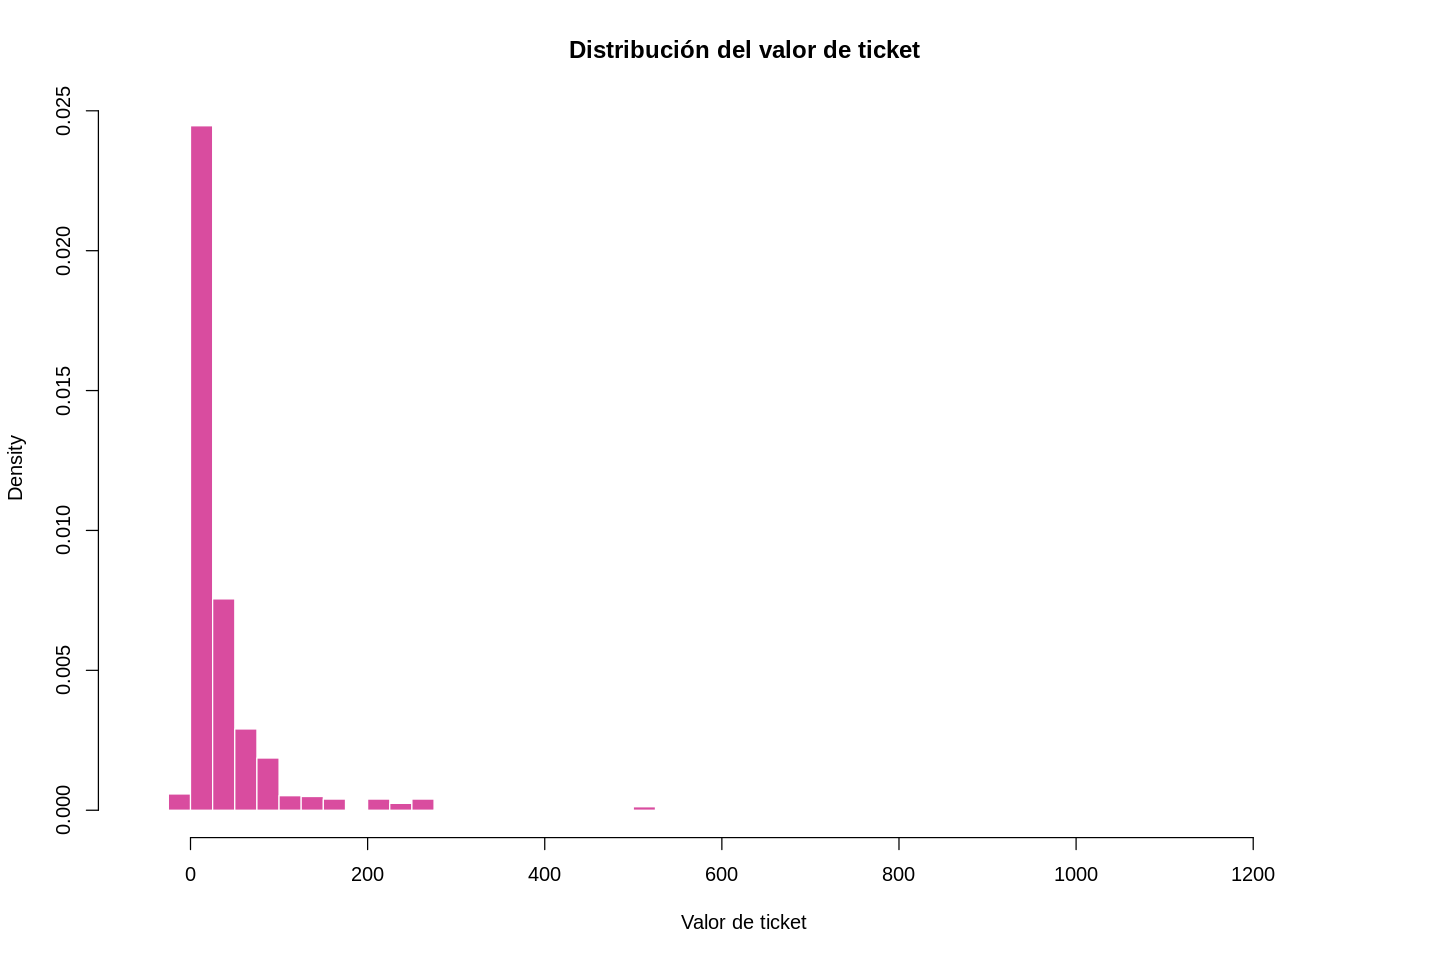

In [ ]:
hist(data_titanic$Fare,
     main = "Distribución del valor de ticket",
     xlab = "Valor de ticket",
     col = '#d94c9f',
     border = "white",
     prob = T, #En este punto indicamos que buscamos conocer la distribución de probablidades y no la de frecuencias
     breaks = seq(-50,1300,25)
    )

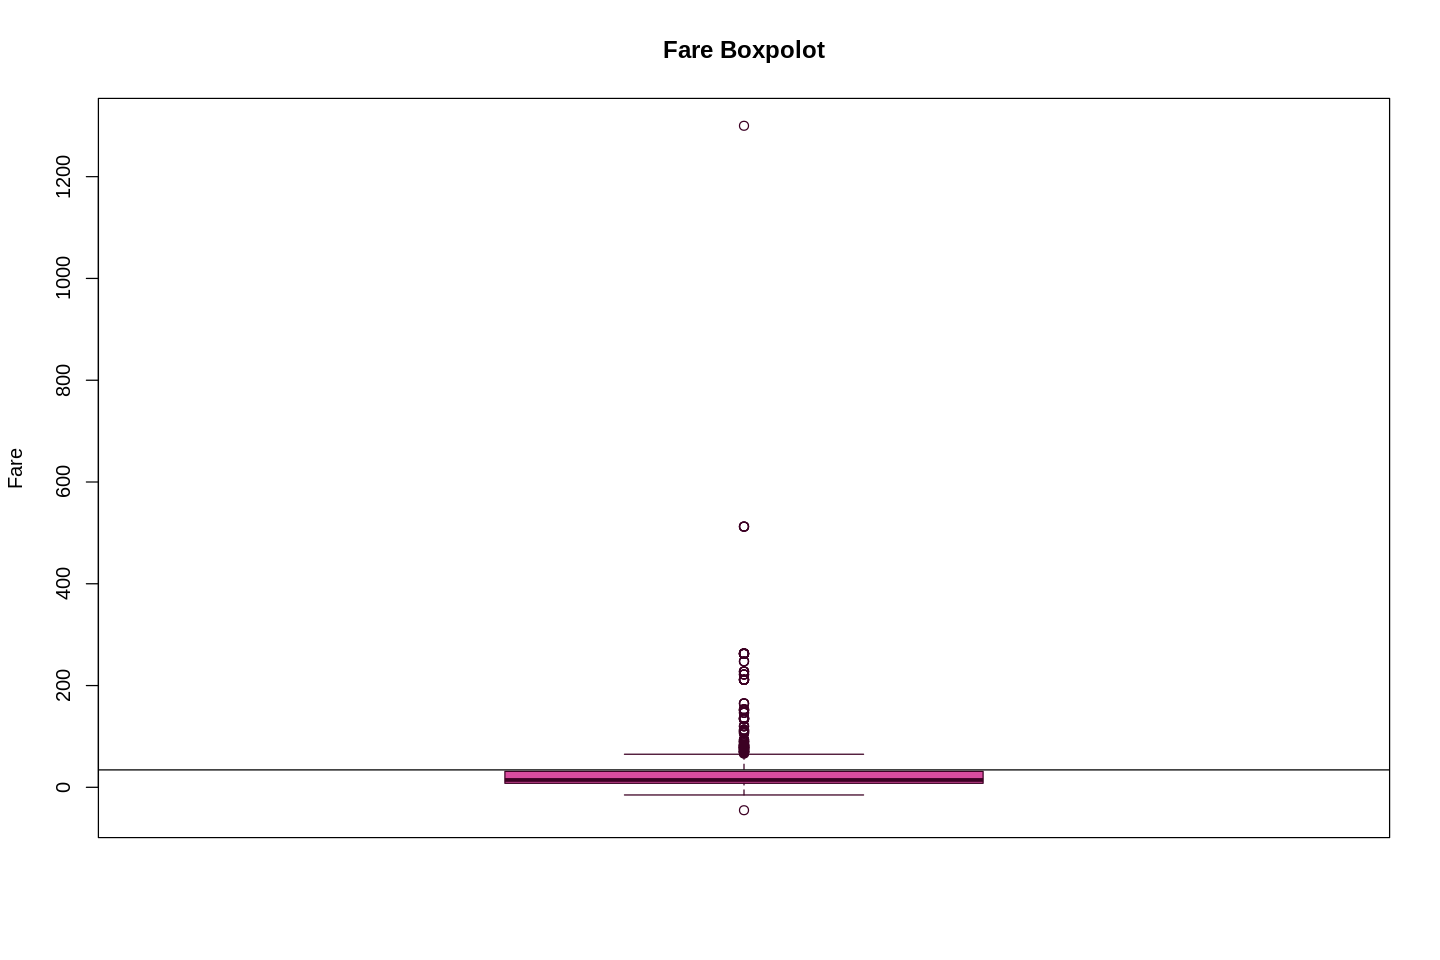

In [ ]:
boxplot(data_titanic$Fare
        ,ylab='Fare'
        ,main='Fare Boxpolot'
        ,col = '#d94c9f'
        ,border = "#3c0023")
abline(h=mean(data_titanic$Fare
              ,na.rm=T))

Podemos apreciar claramente que hay dos tipos de instancias que podemos catalogar como outlayers:

- Valores de fare negativos: Es esto posible?
- Valores de fare muy altos: Hay 2 instancias con un valor demasiado alto

En este caso procedemos a retirarlos dado que hay muy pocas instancias con estos valores y rompen completamente la visualización

In [ ]:
# Primero filtramos:
data_titanic_Filtrado = subset(data_titanic, Fare > 0)
data_titanic_Filtrado = subset(data_titanic_Filtrado, Fare < 300)

# Summary
print("Summary de Fare:")
summary(data_titanic_Filtrado$Fare)

[1] "Summary de Fare:"


   Min. 1st Qu.  Median    Mean 3rd Qu.    Max. 
  3.171   7.925  14.500  32.309  31.275 263.000 

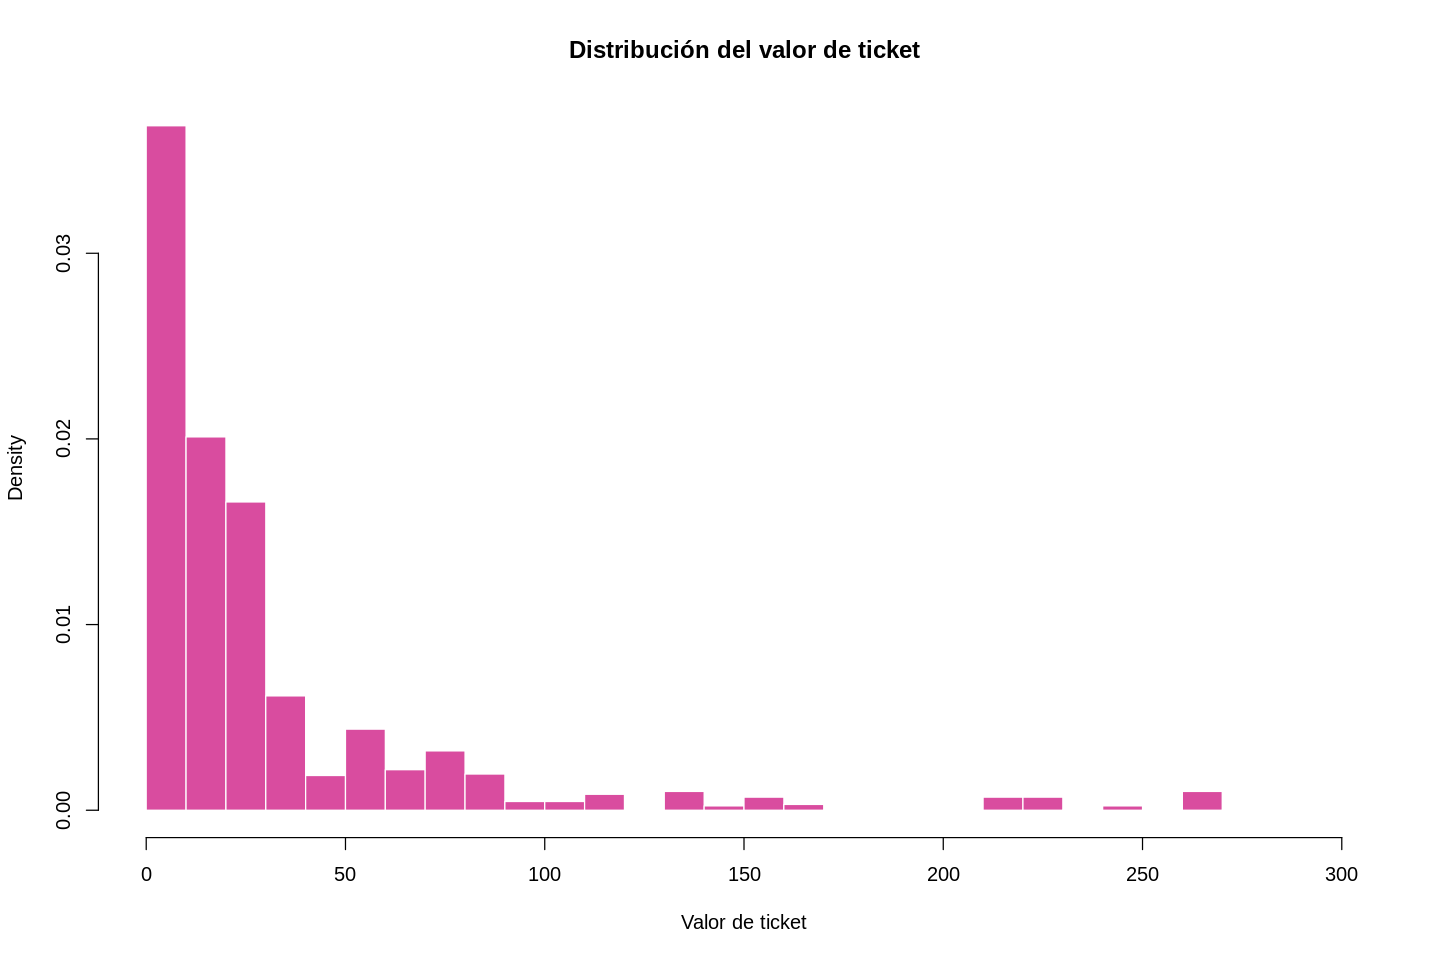

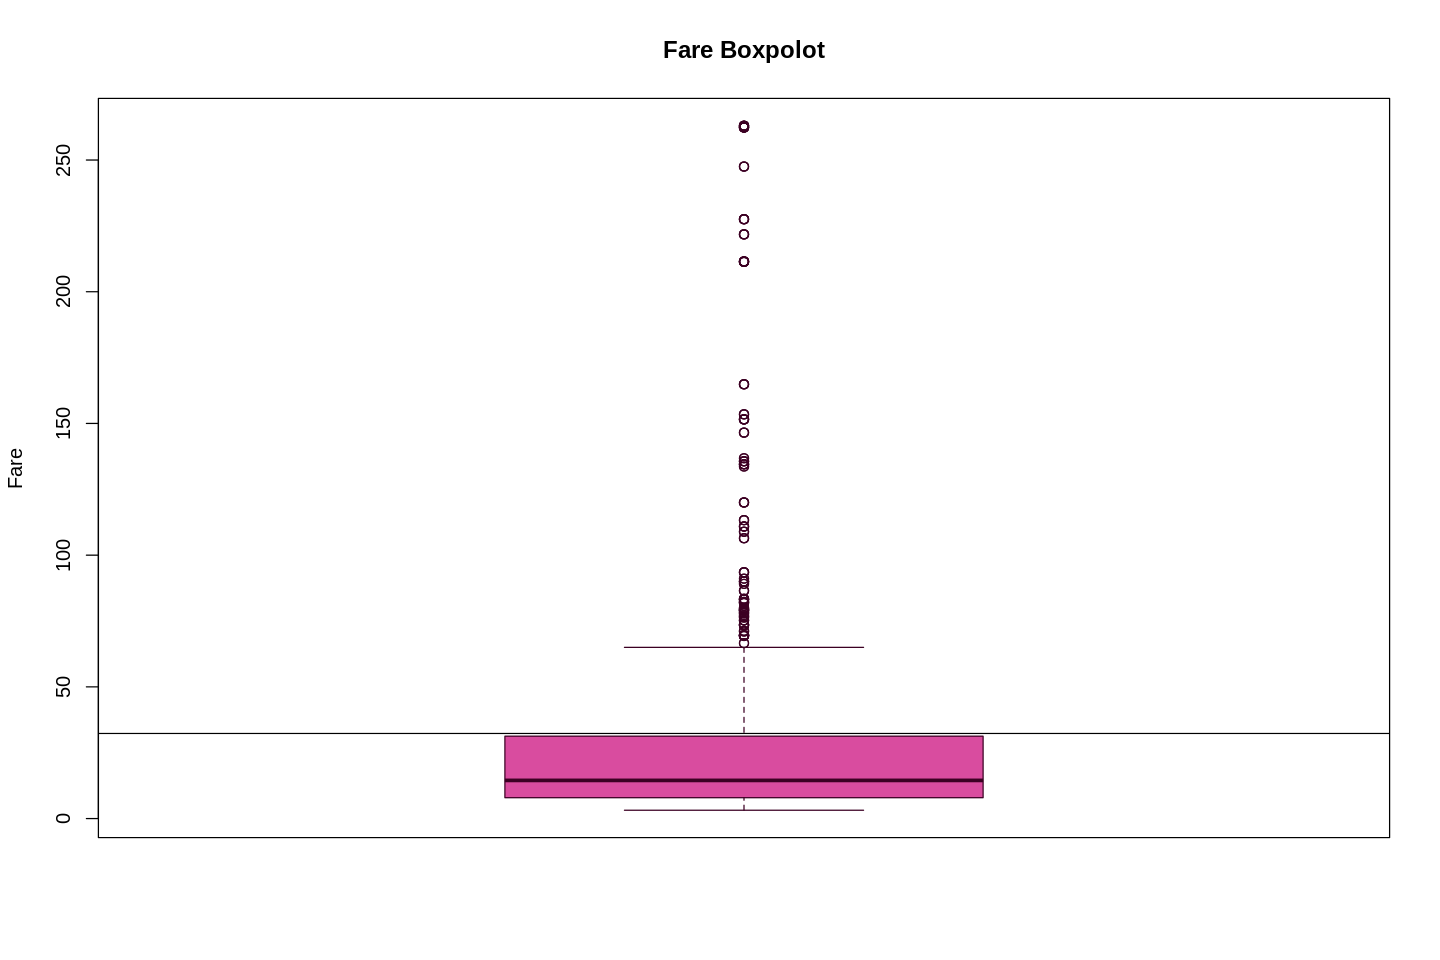

In [ ]:
hist(data_titanic_Filtrado$Fare,
     main = "Distribución del valor de ticket",
     xlab = "Valor de ticket",
     col = '#d94c9f',
     border = "white",
     prob = T, #En este punto indicamos que buscamos conocer la distribución de probablidades y no la de frecuencias
     breaks = seq(0,300,10)
    )
boxplot(data_titanic_Filtrado$Fare
        ,ylab='Fare'
        ,main='Fare Boxpolot'
        ,col = '#d94c9f'
        ,border = "#3c0023")
abline(h=mean(data_titanic_Filtrado$Fare
              ,na.rm=T))

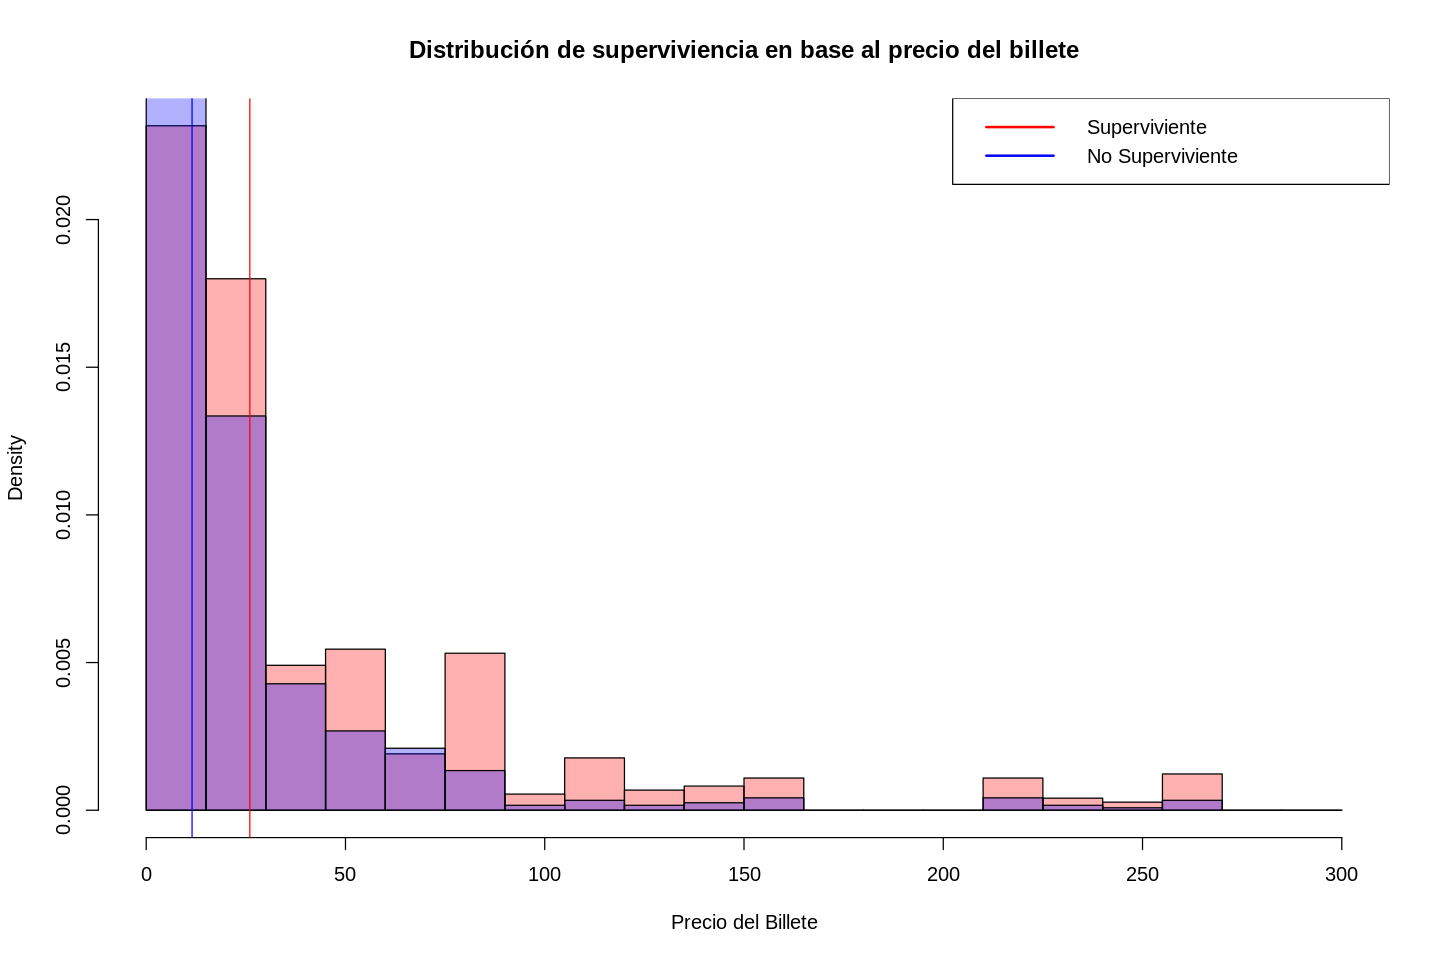

In [ ]:
options(repr.plot.width=12, repr.plot.height=8)
# Aproximación lineal de las curvas de densidad
hist(subset(data_titanic_Filtrado,Survived == 1)[,'Fare']
     , col = rgb(1,0,0,0.3)
     , prob = T #En este punto indicamos que buscamos conocer la distribución de probablidades y no la de frecuencias
     , breaks = seq(0,300,15)
     , main = 'Distribución de superviviencia en base al precio del billete'
     , xlab = 'Precio del Billete')

hist(subset(data_titanic_Filtrado,Survived == 0)[,'Fare']
     , col = rgb(0,0,1,0.3)
     , prob = T #En este punto indicamos que buscamos conocer la distribución de probablidades y no la de frecuencias
     , breaks = seq(0,300,15)
     , add = T)

# Añadimos una leyenda para entender cada distribución
legend("topright"
       , c("Superviviente", "No Superviviente")
       , col = c(rgb(1,0,0), rgb(0,0,1))
       , lwd=2)
# Median values of the 'FL' Metric by species
abline(v = median(subset(data_titanic_Filtrado,Survived == 1)[,'Fare'])
       , col = "red")
abline(v = median(subset(data_titanic_Filtrado,Survived == 0)[,'Fare'])
       , col = "blue")

In [ ]:
data_titanic_Filtrado  %>%
    group_by(Survived)  %>%
    summarize(passengers = n(), mean_fare = mean(Fare), median_fare = quantile(Fare, probs = 0.5), sd_fare = sd(Fare))

Survived,passengers,mean_fare,median_fare,sd_fare
<int>,<int>,<dbl>,<dbl>,<dbl>
0,794,24.41972,11.5,35.16652
1,489,45.11976,26.0,54.53262


Si bien apreciamos una ligera diferencia en las distribuciones superiores nos encontramos con que a nivel medio hay una gran diferencia entre la probabilidad de supervivencia en función del precio del ticket:

## <font color='#3d59c6'>  4. Datos FALTANTES: Variable Clase asociada al ticket</font>

Una gran parte de la preparación de datos se trata de valores perdidos en su conjunto de datos. Hay varios trucos que puede aplicar para manejar los valores faltantes que se enumeran a continuación:

<b>1.</b> Puede eliminar los valores faltantes (solo si tiene una buena razón, por ejemplo, el número de valores desconocidos en una observación / fila es tan alto que los datos parecen inutilizables).

<b>2.</b> Puede usar medidas de tendencia central (media, moda, mediana) para completar los valores faltantes. Debe pensar cuidadosamente sobre esto, ya que esto puede tener consecuencias indeseables para las variables con valores atípicos.

<b>3.</b> Use similitud entre casos. Aquí puede agrupar observaciones relacionadas y luego usar las medidas de tendencia central para inferir los valores faltantes.

<b>4.</b> Use ecuaciones para calcular valores perdidos basados en correlaciones. Un ejemplo de esto es usar la regresión lineal para inferir los valores faltantes de "Fare" en el conjunto de datos Titanic como se muestra en el siguiente ejemplo. El primer paso es identificar una columna que esté correlacionada con la que está intentando llenar. Como mostramos en el paso de correlación, "Fare" y "Pclass" están correlacionadas. Usaremos "Pclass" como nuestra variable independiente en el modelo de regresión de la siguiente manera:

In [ ]:
data_titanic_Filtrado  %>%
    group_by(Pclass)  %>%
    summarize(passengers = n()
              , mean_fare = mean(Fare)
              , median_fare = quantile(Fare, probs = 0.5))

Pclass,passengers,mean_fare,median_fare
<int>,<int>,<dbl>,<dbl>
0,2,10.38750,10.38750
1,308,84.26546,61.27710
2,266,21.80879,15.75000
3,691,13.44985,8.05000
NA,16,23.95599,8.65835


In [ ]:
# Generamos un modelo con las instancias con valores conocidos
data_fares = data_titanic_Filtrado[data_titanic_Filtrado$Pclass %in% c(1, 2, 3),]

modelo_fares = glm(formula = Pclass ~ Fare
                  , data = data_fares)
print(modelo_fares)
modelo_fares$coefficients


Call:  glm(formula = Pclass ~ Fare, data = data_fares)

Coefficients:
(Intercept)         Fare  
    2.67462     -0.01146  

Degrees of Freedom: 1264 Total (i.e. Null);  1263 Residual
Null Deviance:	    883 
Residual Deviance: 549.7 	AIC: 2542


(Intercept)        Fare 
 2.67462104 -0.01145944

In [ ]:
# Model Predictions:
data.frame(round(predict(modelo_fares),0)) %>%
    group_by(round.predict.modelo_fares...0.) %>%
    summarize(n())

round.predict.modelo_fares...0.,n()
<dbl>,<int>
0,34
1,45
2,541
3,645


In [ ]:
# Generamos una predicción de clases más correcta:
p = ifelse(round(predict(modelo_fares),0)<1,1,round(predict(modelo_fares),0))
data.frame(p) %>%
    group_by(p) %>%
    summarize(n())

p,n()
<dbl>,<int>
1,79
2,541
3,645


In [ ]:
confusionMatrix(
    as.factor(p)
    ,as.factor(data_fares$Pclass))

Confusion Matrix and Statistics

          Reference
Prediction   1   2   3
         1  79   0   0
         2 229 135 177
         3   0 131 514

Overall Statistics
                                          
               Accuracy : 0.5755          
                 95% CI : (0.5477, 0.6029)
    No Information Rate : 0.5462          
    P-Value [Acc > NIR] : 0.01948         
                                          
                  Kappa : 0.3113          
                                          
 Mcnemar's Test P-Value : NA              

Statistics by Class:

                     Class: 1 Class: 2 Class: 3
Sensitivity           0.25649   0.5075   0.7438
Specificity           1.00000   0.5936   0.7718
Pos Pred Value        1.00000   0.2495   0.7969
Neg Pred Value        0.80691   0.8191   0.7145
Prevalence            0.24348   0.2103   0.5462
Detection Rate        0.06245   0.1067   0.4063
Detection Prevalence  0.06245   0.4277   0.5099
Balanced Accuracy     0.62825   0.5506   

In [ ]:
#se genera un subconjunto a partir de datos_titanic_filtrados, en el que solo se cogen las instancias con valores faltantes. (diferentes a 1,2,3)
na_class = data_titanic_Filtrado[!(data_titanic_Filtrado$Pclass %in% c(1, 2, 3)),]
head(na_class)

,PassengerId,Survived,Pclass,Name,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked,Gender,Gender_opt2,AgeNumeric
,<int>,<int>,<int>,<chr>,<chr>,<int>,<int>,<chr>,<dbl>,<chr>,<chr>,<chr>,<chr>,<dbl>
18,18,1,0,"Williams, Mr. Charles Eugene",,0,0,244373,13.0000,,S,Man,Man,NA
23,23,1,NA,"McGowan, Miss. Anna ""Annie""",15,0,0,330923,8.0292,,Q,Woman,Woman,15
45,45,1,NA,"Devaney, Miss. Margaret Delia",19,0,0,330958,7.8792,,Q,Woman,Woman,19
104,104,0,NA,"Johansson, Mr. Gustaf Joel",33,0,0,7540,8.6542,,S,Man,Man,33
111,111,0,NA,"Porter, Mr. Walter Chamberlain",47,0,0,110465,52.0000,C110,S,Man,Man,47
133,133,0,NA,"Robins, Mrs. Alexander A (Grace Charity Laury)",47,1,0,A/5. 3337,14.5000,,S,Woman,Woman,47


Con estas instancias generamos nuestras predicciones:

In [ ]:
head(round(predict(modelo_fares, newdata = data.frame(Fare = na_class$Fare)),0))

1 2 3 4 5 6 
3 3 3 3 2 3

In [ ]:
na_class$pred_Pclass = round(predict(modelo_fares, newdata = data.frame(Fare = na_class$Fare)),0)
head(na_class)

,PassengerId,Survived,Pclass,Name,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked,Gender,Gender_opt2,AgeNumeric,pred_Pclass
,<int>,<int>,<int>,<chr>,<chr>,<int>,<int>,<chr>,<dbl>,<chr>,<chr>,<chr>,<chr>,<dbl>,<dbl>
18,18,1,0,"Williams, Mr. Charles Eugene",,0,0,244373,13.0000,,S,Man,Man,NA,3
23,23,1,NA,"McGowan, Miss. Anna ""Annie""",15,0,0,330923,8.0292,,Q,Woman,Woman,15,3
45,45,1,NA,"Devaney, Miss. Margaret Delia",19,0,0,330958,7.8792,,Q,Woman,Woman,19,3
104,104,0,NA,"Johansson, Mr. Gustaf Joel",33,0,0,7540,8.6542,,S,Man,Man,33,3
111,111,0,NA,"Porter, Mr. Walter Chamberlain",47,0,0,110465,52.0000,C110,S,Man,Man,47,2
133,133,0,NA,"Robins, Mrs. Alexander A (Grace Charity Laury)",47,1,0,A/5. 3337,14.5000,,S,Woman,Woman,47,3


In [ ]:
#En resumen, está agregando las predicciones (pred_Pclass) del modelo al conjunto de datos data_titanic_Filtrado utilizando la columna PassengerId como clave de unión.
data_titanic_Filtrado = data_titanic_Filtrado %>%
    left_join((na_class %>% select(PassengerId, pred_Pclass)), by = "PassengerId")

#Como solo se generaron prediciones para las instancias qeu "pclass" era nulo, hay muchoas predicciones que son ahora nulas.
#crea una nueva variable que si la prediccion p_class de esa instancia es nula, se pone el valor original P_class, si no se pone el valor de pred_pclass.
data_titanic_Filtrado$Pclass_est = ifelse(is.na(data_titanic_Filtrado$pred_Pclass)
                                  , data_titanic_Filtrado$Pclass
                                  , data_titanic_Filtrado$pred_Pclass)

head(data_titanic_Filtrado)

,PassengerId,Survived,Pclass,Name,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked,Gender,Gender_opt2,AgeNumeric,pred_Pclass,Pclass_est
,<int>,<int>,<int>,<chr>,<chr>,<int>,<int>,<chr>,<dbl>,<chr>,<chr>,<chr>,<chr>,<dbl>,<dbl>,<dbl>
1,1,0,3,"Braund, Mr. Owen Harris",22,1,0,A/5 21171,7.2500,,S,Man,Man,22,NA,3
2,2,1,1,"Cumings, Mrs. John Bradley (Florence Briggs Thayer)",38,1,0,PC 17599,71.2833,C85,C,Woman,Woman,38,NA,1
3,3,1,3,"Heikkinen, Miss. Laina",26,0,0,STON/O2. 3101282,7.9250,,S,Woman,Woman,26,NA,3
4,4,1,1,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",35,1,0,113803,53.1000,C123,S,Woman,Woman,35,NA,1
5,5,0,3,"Allen, Mr. William Henry",35,0,0,373450,8.0500,,S,Man,Man,35,NA,3
6,6,0,3,"Moran, Mr. James",,0,0,330877,8.4583,,Q,Man,Man,NA,NA,3


In [ ]:
data_titanic_Filtrado  %>%
    group_by(Pclass_est)  %>%
    summarize(passengers = n()
              , mean_fare = mean(Fare)
              , median_fare = quantile(Fare, probs = 0.5))

Pclass_est,passengers,mean_fare,median_fare
<dbl>,<int>,<dbl>,<dbl>
1,309,84.48940,61.3792
2,269,22.00929,15.7500
3,705,13.36893,8.0500


## <font color='#3d59c6'>  5. Normalización: Variable Edad</font>

la normalización es una técnica utilizada para transformar escalas de variables medidas en diferentes escalas en una escala comparable o común. Puede tener la variable "Age" que va de 0 a 95 y otra variable "Ingresos" que va de 0 a 10 000 000.
Estas escalas diferentes pueden tener un efecto negativo en el rendimiento de su modelo, pero al usar la normalización, estas variables se pueden transformar en una escala de valores entre 0 y 1.

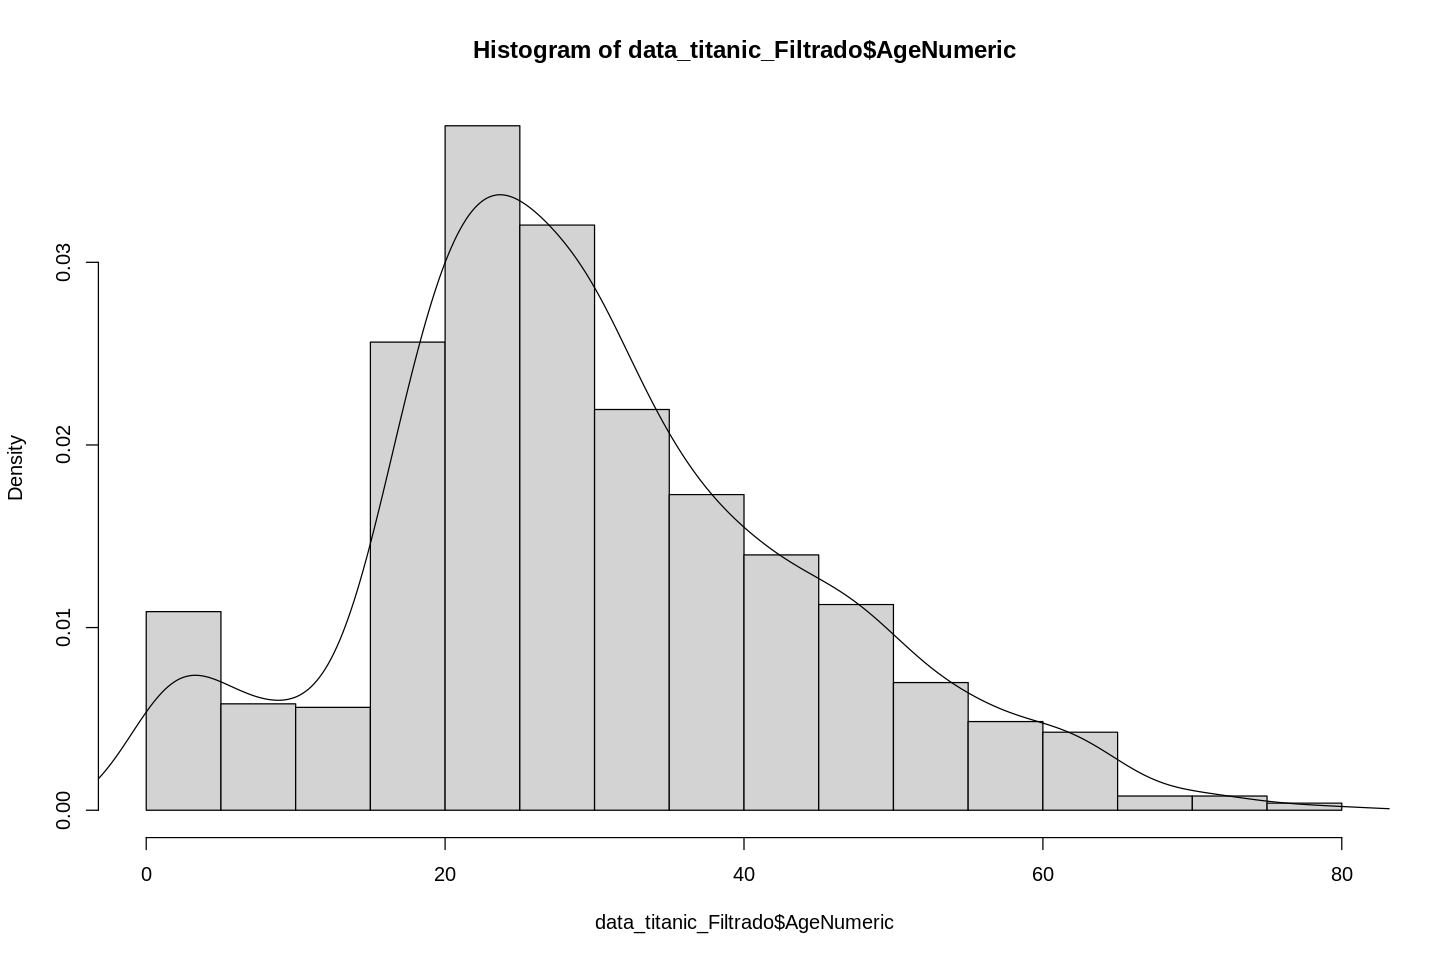

In [ ]:
hist(data_titanic_Filtrado$AgeNumeric,prob=T)
lines(density(data_titanic_Filtrado$AgeNumeric,na.rm=T))
#adds smooth line and DROP NA's

In [ ]:
data_titanic_Filtrado$AgeNormalised = decostand(x=data_titanic_Filtrado$AgeNumeric,"normalize", 2, na.rm=TRUE)
head(data_titanic_Filtrado,6)

,PassengerId,Survived,Pclass,Name,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked,Gender,Gender_opt2,AgeNumeric,pred_Pclass,Pclass_est,AgeNormalised
,<int>,<int>,<int>,<chr>,<chr>,<int>,<int>,<chr>,<dbl>,<chr>,<chr>,<chr>,<chr>,<dbl>,<dbl>,<dbl>,"<dbl[,1]>"
1,1,0,3,"Braund, Mr. Owen Harris",22,1,0,A/5 21171,7.2500,,S,Man,Man,22,NA,3,0.02073144
2,2,1,1,"Cumings, Mrs. John Bradley (Florence Briggs Thayer)",38,1,0,PC 17599,71.2833,C85,C,Woman,Woman,38,NA,1,0.03580886
3,3,1,3,"Heikkinen, Miss. Laina",26,0,0,STON/O2. 3101282,7.9250,,S,Woman,Woman,26,NA,3,0.02450080
4,4,1,1,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",35,1,0,113803,53.1000,C123,S,Woman,Woman,35,NA,1,0.03298184
5,5,0,3,"Allen, Mr. William Henry",35,0,0,373450,8.0500,,S,Man,Man,35,NA,3,0.03298184
6,6,0,3,"Moran, Mr. James",,0,0,330877,8.4583,,Q,Man,Man,NA,NA,3,NA


Como se puede ver en la salida anterior, la columna normalizada resultante tiene valores entre 0-1. El inconveniente de la normalización es que se pierden los valores atípicos ya que todo se ajusta a pequeña escala. La respuesta a esto es la estandarización que se explica a continuación.

## <font color='#3d59c6'>  6. Estandarización: Variable Edad</font>

Habrá momentos en los que se desee normalizar sus variables pero aún así mantener las ponderaciones de cada valor individual, incluidos los valores atípicos, en estas circunstancias es preferible utilizar la estandarización. La estandarización transformará su variable para que tenga una media cero y variación de unidad / desviación estándar.

In [ ]:
data_titanic_Filtrado$AgeStandardised = scale(data_titanic_Filtrado[,"AgeNormalised"])
head(data_titanic_Filtrado,6)

,PassengerId,Survived,Pclass,Name,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked,Gender,Gender_opt2,AgeNumeric,pred_Pclass,Pclass_est,AgeNormalised,AgeStandardised
,<int>,<int>,<int>,<chr>,<chr>,<int>,<int>,<chr>,<dbl>,<chr>,<chr>,<chr>,<chr>,<dbl>,<dbl>,<dbl>,"<dbl[,1]>","<dbl[,1]>"
1,1,0,3,"Braund, Mr. Owen Harris",22,1,0,A/5 21171,7.2500,,S,Man,Man,22,NA,3,0.02073144,-0.5379974
2,2,1,1,"Cumings, Mrs. John Bradley (Florence Briggs Thayer)",38,1,0,PC 17599,71.2833,C85,C,Woman,Woman,38,NA,1,0.03580886,0.5715018
3,3,1,3,"Heikkinen, Miss. Laina",26,0,0,STON/O2. 3101282,7.9250,,S,Woman,Woman,26,NA,3,0.02450080,-0.2606226
4,4,1,1,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",35,1,0,113803,53.1000,C123,S,Woman,Woman,35,NA,1,0.03298184,0.3634707
5,5,0,3,"Allen, Mr. William Henry",35,0,0,373450,8.0500,,S,Man,Man,35,NA,3,0.03298184,0.3634707
6,6,0,3,"Moran, Mr. James",,0,0,330877,8.4583,,Q,Man,Man,NA,NA,3,NA,NA


Del resultado resultante se puede ver que la variable Age estandarizada ahora está en una escala nueva y más pequeña en comparación con la escala de variables original.

## <font color='#3d59c6'>  6. Discretización / Agrupación: Variable Edad</font>

Como se puede ver arriba, el resultado es una nueva columna que tiene diferentes categorías para la variable Age. Hay otras formas de diferenciar sus variables, como usar intervalos de frecuencia iguales o intervalos de longitud iguales.

In [ ]:
data_titanic_Filtrado$AgeClass = as.factor(
    ifelse(data_titanic_Filtrado$AgeNumeric<=3,'Infant',
    ifelse(data_titanic_Filtrado$AgeNumeric>3 & data_titanic_Filtrado$AgeNumeric<=12,'Child',
    ifelse(data_titanic_Filtrado$AgeNumeric>12 & data_titanic_Filtrado$AgeNumeric<=19,'Teenager',
    ifelse(data_titanic_Filtrado$AgeNumeric>20 & data_titanic_Filtrado$AgeNumeric<=35,'Young Adult',
    ifelse(data_titanic_Filtrado$AgeNumeric>35 & data_titanic_Filtrado$AgeNumeric<=45,'Middle Age', 'Elderly'))))))

data_titanic_Filtrado  %>%
    group_by(AgeClass) %>%
    summarize(n())

AgeClass,n()
<fct>,<int>
Child,53
Elderly,174
Infant,41
Middle Age,161
Teenager,130
Young Adult,471
NA,253
